# MERIDIAN PII Detection — Model 4: DeBERTa Transformer
**NLP Final Project — BC Analytics Capstone**

This notebook fine-tunes a DeBERTa-v3-base model for token-level PII detection
using the Kaggle PII Data Detection competition dataset.

**Runtime:** Go to Runtime → Change runtime type → Select **T4 GPU**

## 1. Setup & Dependencies

In [17]:
!pip install -q transformers datasets seqeval accelerate kaggle

In [18]:
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU Available: True
GPU: Tesla T4
Memory: 15.6 GB


## 2. Download Kaggle Dataset
Upload your `kaggle.json` file when prompted.

In [19]:
import os
from google.colab import files

uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
# Handle any filename
for filename, content in uploaded.items():
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(content)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle competitions download -c pii-detection-removal-from-educational-data
!unzip -q -o pii-detection-removal-from-educational-data.zip -d data/
!ls data/

Saving kaggle.json to kaggle (2).json
pii-detection-removal-from-educational-data.zip: Skipping, found more recently modified local copy (use --force to force download)
sample_submission.csv  test.json  train.json


## 3. Load & Explore Data

In [20]:
import json
import numpy as np
from collections import Counter

with open('data/train.json', 'r') as f:
    raw_data = json.load(f)

print(f"Total documents: {len(raw_data)}")
print(f"First doc tokens: {len(raw_data[0]['tokens'])}")

# Label distribution
all_labels = []
for doc in raw_data:
    all_labels.extend([l for l in doc['labels'] if l != 'O'])

print(f"\nTotal PII tokens: {len(all_labels)}")
print("\nPII Label Distribution:")
for label, count in Counter(all_labels).most_common():
    print(f"  {label}: {count}")

Total documents: 6807
First doc tokens: 753

Total PII tokens: 2739

PII Label Distribution:
  B-NAME_STUDENT: 1365
  I-NAME_STUDENT: 1096
  B-URL_PERSONAL: 110
  B-ID_NUM: 78
  B-EMAIL: 39
  I-STREET_ADDRESS: 20
  I-PHONE_NUM: 15
  B-USERNAME: 6
  B-PHONE_NUM: 6
  B-STREET_ADDRESS: 2
  I-URL_PERSONAL: 1
  I-ID_NUM: 1


## 4. Configuration & Label Definitions

In [21]:
# PII Labels (BIO tagging scheme)
PII_LABELS = [
    "O",
    "B-NAME_STUDENT",  "I-NAME_STUDENT",
    "B-EMAIL",         "I-EMAIL",
    "B-USERNAME",      "I-USERNAME",
    "B-ID_NUM",        "I-ID_NUM",
    "B-PHONE_NUM",     "I-PHONE_NUM",
    "B-URL_PERSONAL",  "I-URL_PERSONAL",
    "B-STREET_ADDRESS","I-STREET_ADDRESS",
]

LABEL2ID = {label: i for i, label in enumerate(PII_LABELS)}
ID2LABEL = {i: label for i, label in enumerate(PII_LABELS)}
NUM_LABELS = len(PII_LABELS)

print(f"Number of labels: {NUM_LABELS}")
print(f"Labels: {PII_LABELS}")

Number of labels: 15
Labels: ['O', 'B-NAME_STUDENT', 'I-NAME_STUDENT', 'B-EMAIL', 'I-EMAIL', 'B-USERNAME', 'I-USERNAME', 'B-ID_NUM', 'I-ID_NUM', 'B-PHONE_NUM', 'I-PHONE_NUM', 'B-URL_PERSONAL', 'I-URL_PERSONAL', 'B-STREET_ADDRESS', 'I-STREET_ADDRESS']


## 5. Data Preprocessing

In [22]:
from sklearn.model_selection import train_test_split

# Use all documents for the transformer (GPU can handle it)
documents = []
for doc in raw_data:
    documents.append({
        'document': doc['document'],
        'tokens': doc['tokens'],
        'labels': doc.get('labels', ['O'] * len(doc['tokens'])),
        'trailing_whitespace': doc['trailing_whitespace'],
    })

# Split: 80/10/10
train_docs, temp_docs = train_test_split(documents, test_size=0.2, random_state=42)
val_docs, test_docs = train_test_split(temp_docs, test_size=0.5, random_state=42)

print(f"Train: {len(train_docs)} | Val: {len(val_docs)} | Test: {len(test_docs)}")

Train: 5445 | Val: 681 | Test: 681


## 6. Tokenization & Label Alignment

In [23]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def align_labels_to_subwords(tokenized_input, original_labels, label2id, ignore_index=-100):
    """Align BIO labels from whitespace tokens to subword tokens."""
    word_ids = tokenized_input.word_ids()
    aligned = []
    prev_word_id = None
    for word_id in word_ids:
        if word_id is None:
            aligned.append(ignore_index)
        elif word_id != prev_word_id:
            lbl = original_labels[word_id] if word_id < len(original_labels) else 'O'
            aligned.append(label2id.get(lbl, 0))
        else:
            lbl = original_labels[word_id] if word_id < len(original_labels) else 'O'
            if lbl.startswith('B-'):
                lbl = 'I-' + lbl[2:]
            aligned.append(label2id.get(lbl, 0))
        prev_word_id = word_id
    return aligned


class PIIDataset(Dataset):
    def __init__(self, documents, tokenizer, max_len=512):
        self.data = []
        for doc in documents:
            encoded = tokenizer(
                doc['tokens'],
                is_split_into_words=True,
                truncation=True,
                max_length=max_len,
                padding='max_length',
                return_tensors='pt',
            )
            aligned = align_labels_to_subwords(encoded, doc['labels'], LABEL2ID)
            aligned = aligned[:max_len]
            aligned += [-100] * (max_len - len(aligned))
            self.data.append({
                'input_ids': encoded['input_ids'].squeeze(),
                'attention_mask': encoded['attention_mask'].squeeze(),
                'labels': torch.tensor(aligned, dtype=torch.long),
            })

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


print("Tokenizing train set...")
train_dataset = PIIDataset(train_docs, tokenizer, MAX_LEN)
print("Tokenizing val set...")
val_dataset = PIIDataset(val_docs, tokenizer, MAX_LEN)
print("Tokenizing test set...")
test_dataset = PIIDataset(test_docs, tokenizer, MAX_LEN)
print(f"\nDataset sizes — Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing train set...
Tokenizing val set...
Tokenizing test set...

Dataset sizes — Train: 5445 | Val: 681 | Test: 681


## 7. Model Training

In [24]:
!pip install evaluate seqeval

In [25]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer
import evaluate

# Load model
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

# Metrics
seqeval = evaluate.load('seqeval')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    true_labels = []
    true_preds = []
    for pred_seq, label_seq in zip(preds, labels):
        t_labels = []
        t_preds = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                t_labels.append(ID2LABEL.get(l, 'O'))
                t_preds.append(ID2LABEL.get(p, 'O'))
        true_labels.append(t_labels)
        true_preds.append(t_preds)
    results = seqeval.compute(
        predictions=true_preds, references=true_labels,
        mode='strict', scheme='IOB2'
    )
    return {
        'precision': results['overall_precision'],
        'recall': results['overall_recall'],
        'f1': results['overall_f1'],
    }


# Training arguments
training_args = TrainingArguments(
    output_dir='./deberta_checkpoints',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    fp16=False,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()
print("Training complete!")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Starting training...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1
1,0.002592,0.003186,0.782178,0.637097,0.702222
2,0.001259,0.001902,0.890000,0.717742,0.794643
3,0.000958,0.001937,0.888889,0.774194,0.827586
4,0.000472,0.001839,0.859649,0.790323,0.823529
5,0.000302,0.001925,0.843478,0.782258,0.811715


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete!


## 8. Evaluation on Test Set

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on test set
predictions = trainer.predict(test_dataset)
pred_logits = predictions.predictions
pred_labels_flat = np.argmax(pred_logits, axis=-1)
true_labels_flat = predictions.label_ids

# Flatten, ignoring -100
y_true = []
y_pred = []
for pred_seq, label_seq in zip(pred_labels_flat, true_labels_flat):
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            y_true.append(ID2LABEL.get(l, 'O'))
            y_pred.append(ID2LABEL.get(p, 'O'))

# Classification report
present_labels = sorted(set(y_true + y_pred))
print(classification_report(y_true, y_pred, labels=present_labels, zero_division=0))

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                precision    recall  f1-score   support

      B-ID_NUM       1.00      0.50      0.67         2
B-NAME_STUDENT       0.94      0.98      0.96       109
B-URL_PERSONAL       0.00      0.00      0.00        15
       I-EMAIL       0.00      0.00      0.00         0
      I-ID_NUM       0.92      0.80      0.86        15
I-NAME_STUDENT       0.90      0.97      0.93       248
I-URL_PERSONAL       0.84      1.00      0.92       228
             O       1.00      1.00      1.00    324977

      accuracy                           1.00    325594
     macro avg       0.70      0.66      0.67    325594
  weighted avg       1.00      1.00      1.00    325594



## 9. Entity-Level F1

In [27]:
def extract_entities(labels):
    entities = []
    current_type = None
    start = None
    for i, label in enumerate(labels):
        if label.startswith('B-'):
            if current_type:
                entities.append((current_type, start, i))
            current_type = label[2:]
            start = i
        elif label.startswith('I-') and current_type == label[2:]:
            continue
        else:
            if current_type:
                entities.append((current_type, start, i))
                current_type = None
    if current_type:
        entities.append((current_type, start, len(labels)))
    return entities

true_entities = set(extract_entities(y_true))
pred_entities = set(extract_entities(y_pred))

tp = len(true_entities & pred_entities)
fp = len(pred_entities - true_entities)
fn = len(true_entities - pred_entities)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Entity-Level Results:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1:        {f1:.4f}")
print(f"  True entities: {len(true_entities)}")
print(f"  Pred entities: {len(pred_entities)}")
print(f"  TP: {tp} | FP: {fp} | FN: {fn}")

Entity-Level Results:
  Precision: 0.8957
  Recall:    0.8175
  F1:        0.8548
  True entities: 126
  Pred entities: 115
  TP: 103 | FP: 12 | FN: 23


## 10. Visualizations

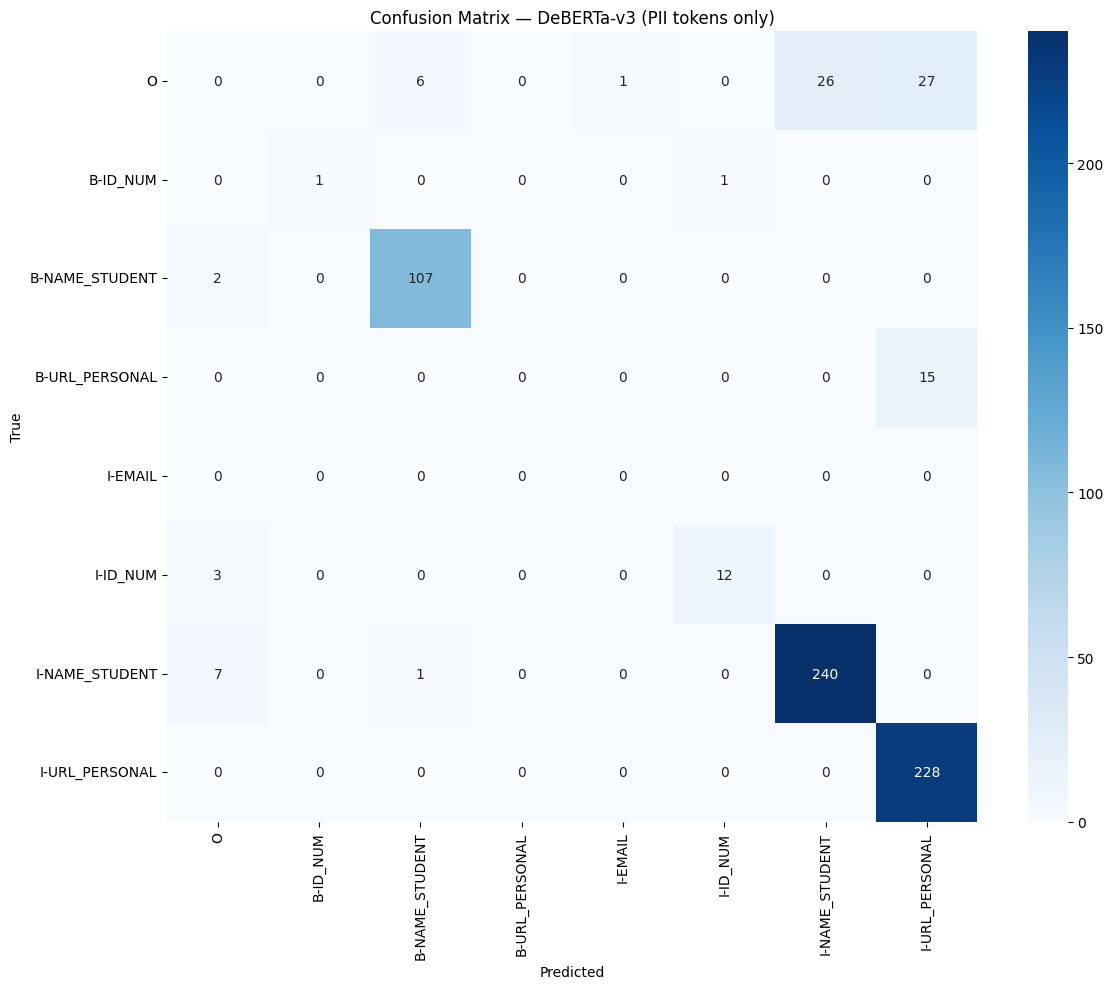

Saved: cm_deberta.png


In [28]:
# Confusion Matrix (PII labels only, excluding 'O')
pii_labels = [l for l in sorted(set(y_true + y_pred)) if l != 'O']

# Filter to only PII tokens for clearer visualization
y_true_pii = []
y_pred_pii = []
for t, p in zip(y_true, y_pred):
    if t != 'O' or p != 'O':
        y_true_pii.append(t)
        y_pred_pii.append(p)

if pii_labels:
    cm_labels = ['O'] + pii_labels
    cm = confusion_matrix(y_true_pii, y_pred_pii, labels=cm_labels)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=cm_labels, yticklabels=cm_labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title('Confusion Matrix — DeBERTa-v3 (PII tokens only)')
    plt.tight_layout()
    plt.savefig('cm_deberta.png', dpi=150)
    plt.show()
    print("Saved: cm_deberta.png")
else:
    print("No PII labels found in predictions.")

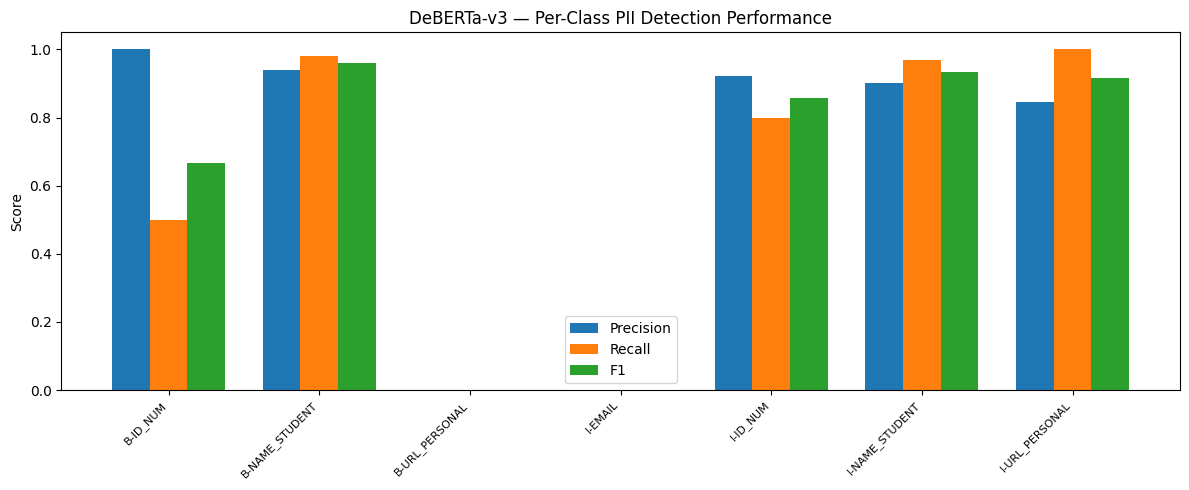

Saved: per_class_deberta.png


In [29]:
# Per-class F1 bar chart
from sklearn.metrics import precision_recall_fscore_support

if pii_labels:
    p, r, f, s = precision_recall_fscore_support(
        y_true, y_pred, labels=pii_labels, zero_division=0
    )
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(pii_labels))
    width = 0.25
    ax.bar(x - width, p, width, label='Precision')
    ax.bar(x, r, width, label='Recall')
    ax.bar(x + width, f, width, label='F1')
    ax.set_xticks(x)
    ax.set_xticklabels(pii_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Score')
    ax.set_title('DeBERTa-v3 — Per-Class PII Detection Performance')
    ax.legend()
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig('per_class_deberta.png', dpi=150)
    plt.show()
    print("Saved: per_class_deberta.png")

In [30]:
# Error analysis — false positives and false negatives
fp_patterns = {}
fn_patterns = {}

for t, p in zip(y_true, y_pred):
    if t == 'O' and p != 'O':
        fp_patterns[p] = fp_patterns.get(p, 0) + 1
    elif t != 'O' and p == 'O':
        fn_patterns[t] = fn_patterns.get(t, 0) + 1

print("False Positive breakdown (O predicted as PII):")
for k, v in sorted(fp_patterns.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}")

print("\nFalse Negative breakdown (PII missed):")
for k, v in sorted(fn_patterns.items(), key=lambda x: -x[1]):
    print(f"  {k}: {v}")

False Positive breakdown (O predicted as PII):
  I-URL_PERSONAL: 27
  I-NAME_STUDENT: 26
  B-NAME_STUDENT: 6
  I-EMAIL: 1

False Negative breakdown (PII missed):
  I-NAME_STUDENT: 7
  I-ID_NUM: 3
  B-NAME_STUDENT: 2


## 11. All Four Models — Summary Comparison
Enter the results from your local runs below to generate a combined comparison chart.

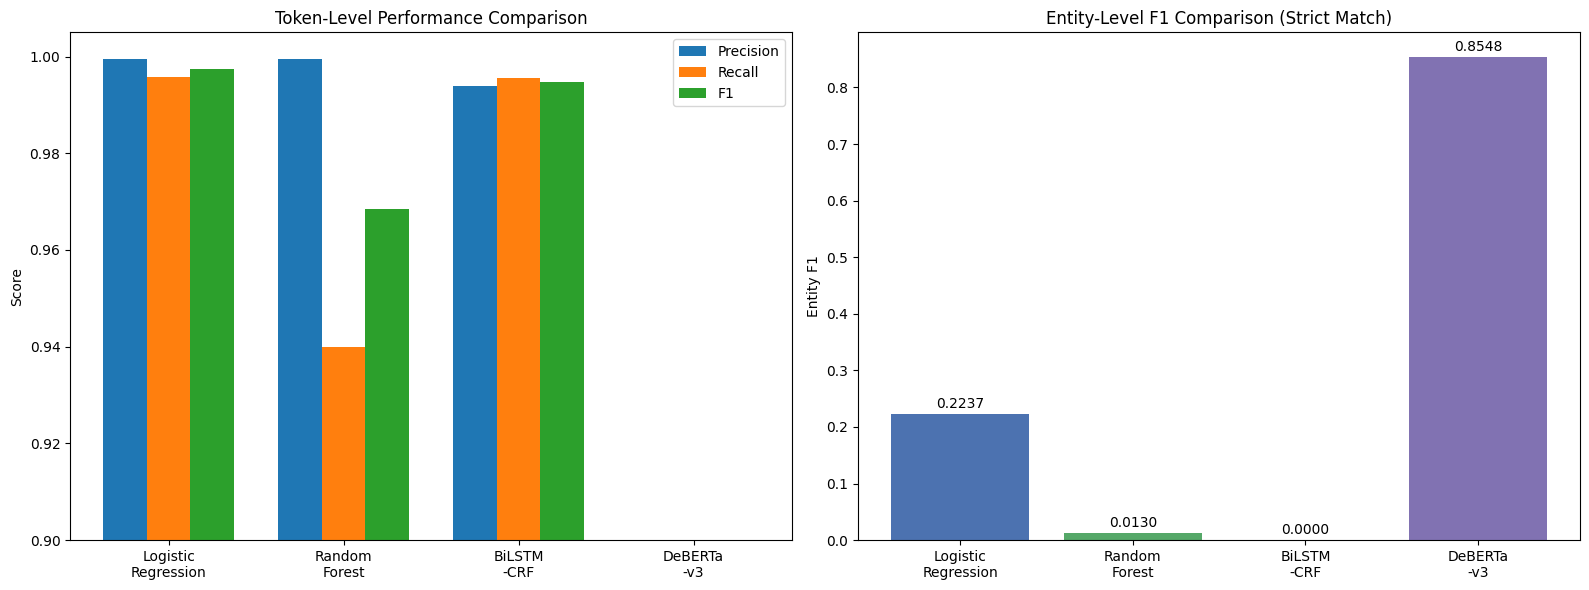

Saved: model_comparison_all.png


In [31]:
# ══════════════════════════════════════════════════
# UPDATE these with your actual DeBERTa results
# after running cells above
# ══════════════════════════════════════════════════
deberta_entity_f1 = f1  # from cell 9

all_results = {
    'Logistic\nRegression': {'precision': 0.9995, 'recall': 0.9958, 'f1': 0.9975, 'entity_f1': 0.2237},
    'Random\nForest':       {'precision': 0.9995, 'recall': 0.9399, 'f1': 0.9685, 'entity_f1': 0.0130},
    'BiLSTM\n-CRF':         {'precision': 0.9939, 'recall': 0.9956, 'f1': 0.9948, 'entity_f1': 0.0000},
    'DeBERTa\n-v3':         {'precision': precision, 'recall': recall, 'f1': f1, 'entity_f1': deberta_entity_f1},
}

# ── Token-level comparison ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = list(all_results.keys())
metrics = ['precision', 'recall', 'f1']
x = np.arange(len(models))
width = 0.25

for i, m in enumerate(metrics):
    vals = [all_results[name][m] for name in models]
    axes[0].bar(x + i * width, vals, width, label=m.capitalize())

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('Score')
axes[0].set_title('Token-Level Performance Comparison')
axes[0].legend()
axes[0].set_ylim(0.9, 1.005)

# ── Entity-level F1 comparison ──
entity_f1s = [all_results[name]['entity_f1'] for name in models]
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
axes[1].bar(models, entity_f1s, color=colors)
axes[1].set_ylabel('Entity F1')
axes[1].set_title('Entity-Level F1 Comparison (Strict Match)')
for i, v in enumerate(entity_f1s):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_all.png', dpi=150)
plt.show()
print("Saved: model_comparison_all.png")

## 12. Download Results
Download the generated visualizations and results.

In [34]:
from google.colab import files

# Save results JSON
import json
results_export = {
    'DeBERTa-v3': {
        'token_precision': float(precision),
        'token_recall': float(recall),
        'token_f1': float(f1),
        'entity_f1': float(deberta_entity_f1),
        'tp': tp, 'fp': fp, 'fn': fn,
    }
}
with open('deberta_results.json', 'w') as f:
    json.dump(results_export, f, indent=2)

# Download all outputs
for fname in ['cm_deberta.png', 'per_class_deberta.png', 'model_comparison_all.png', 'deberta_results.json']:
    try:
        files.download(fname)
    except:
        print(f"Could not download {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>